In [1]:
from src import *

- Initialisation of the hyperparameters 

In [2]:
L = 40  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

### Tuning of the parameters $k_\lambda$ and $m_\lambda$ over a uniform grid of size $L$

Lambda grid: 100%|██████████| 41/41 [00:00<00:00, 47.23it/s]


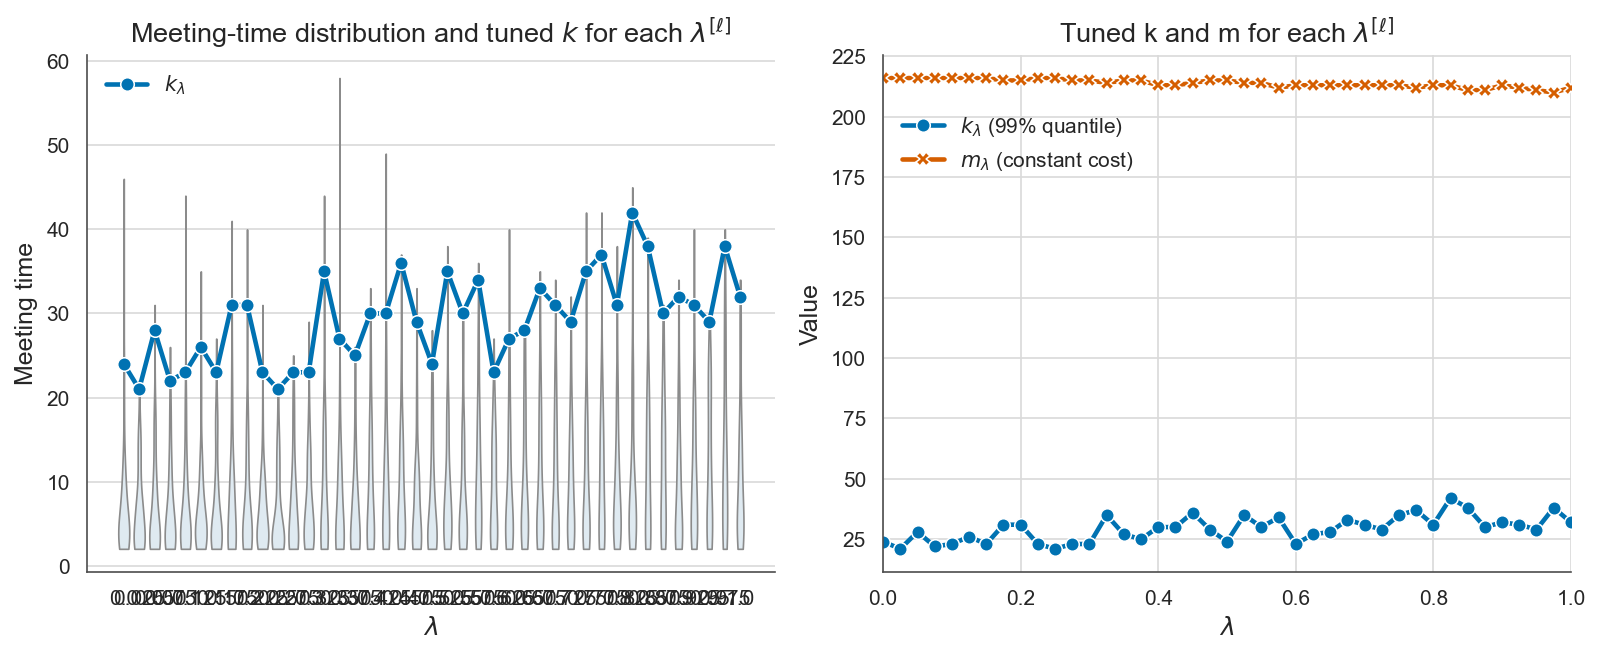

In [3]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)

### Variance of the UMCMC estimator and the second moment over the grid 
- $\hat{E}(\lambda)$ is the UMCMC of the expectation $\mathbb{E}_{\pi_\lambda}[\nabla_\lambda \log \pi_\lambda]$

Final estimation: 100%|██████████| 41/41 [00:11<00:00,  3.55it/s]


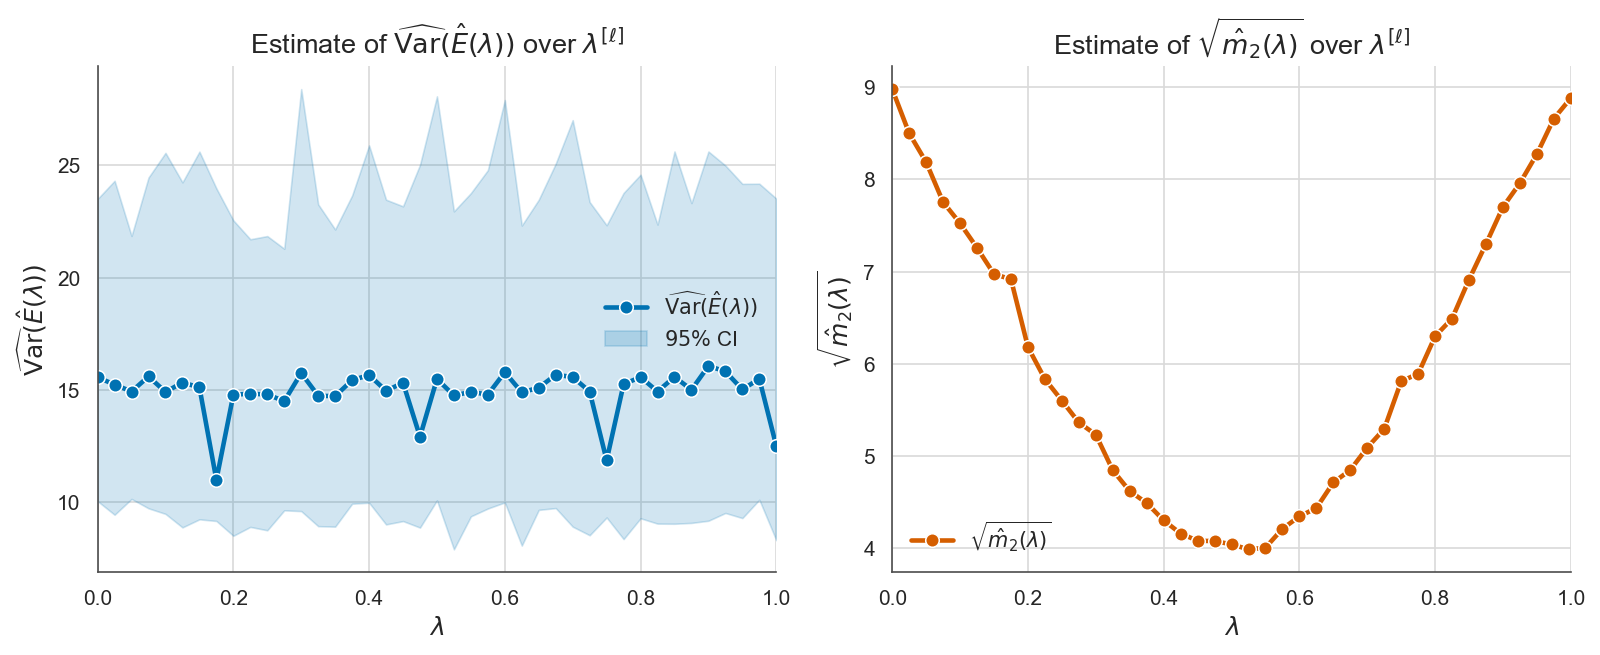

In [4]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag)

### Now try various startified estimators 

In [5]:


def random_budget_allocation(L, M):
    if M < L:
        raise ValueError("M must be at least L so each bin gets at least one sample.")

    # Give one sample to each bin, then distribute the remaining budget randomly.
    budget = np.ones(L, dtype=int)
    remaining = M - L

    if remaining > 0:
        extra = np.random.multinomial(remaining, np.ones(L) / L)
        budget += extra

    return budget



In [6]:
M = 40
L = 20
L_initial = M//2
L_final = M 
M_budget = random_budget_allocation(L, M)
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag)


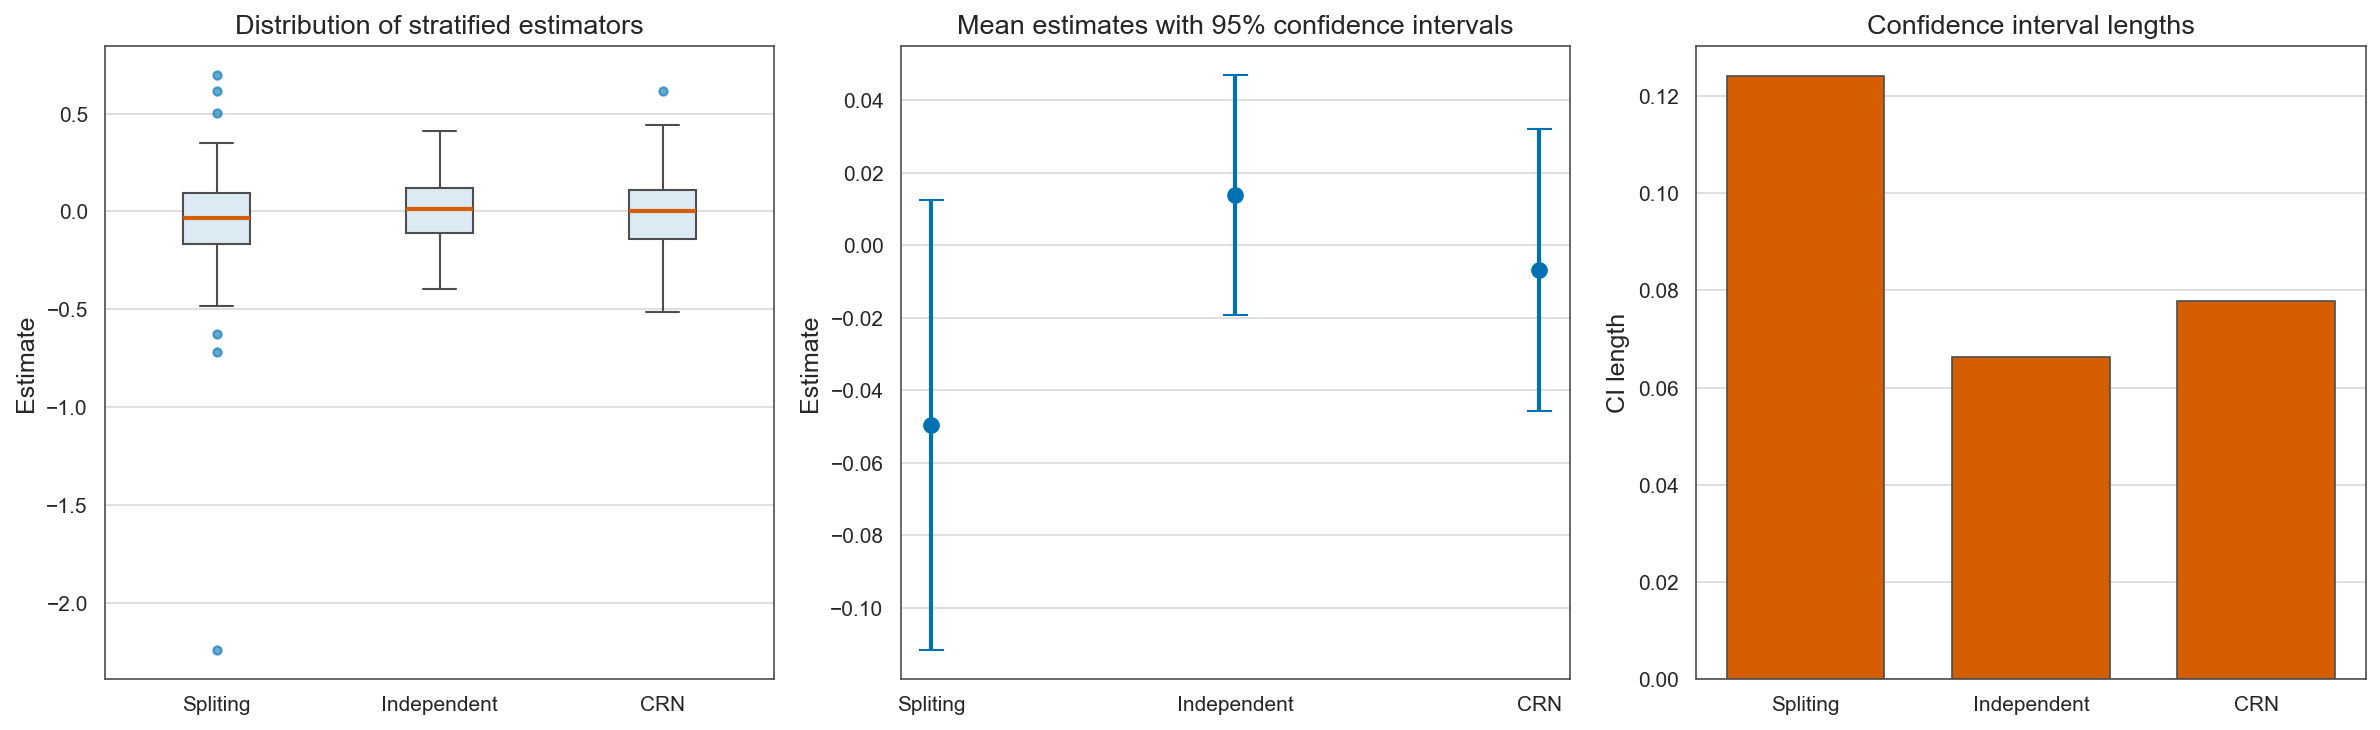

Spliting: CI length = 0.124168
Independent: CI length = 0.066378
CRN: CI length = 0.077814


In [7]:
estimators = [
    lambda: stratified_estimator_splitting(L_final, estimator, initial_L=L_initial, n_samples=5),
    lambda: stratified_estimator_indepdent(L, M_budget, estimator),
    lambda: stratified_estimator_crn(L, M_budget, estimator),
]

labels = ["Spliting", "Independent", "CRN"]

res = plot_estimators_box_CI(
    estimators,
    labels,
    nrep=100,
    ci_level=0.95,
)


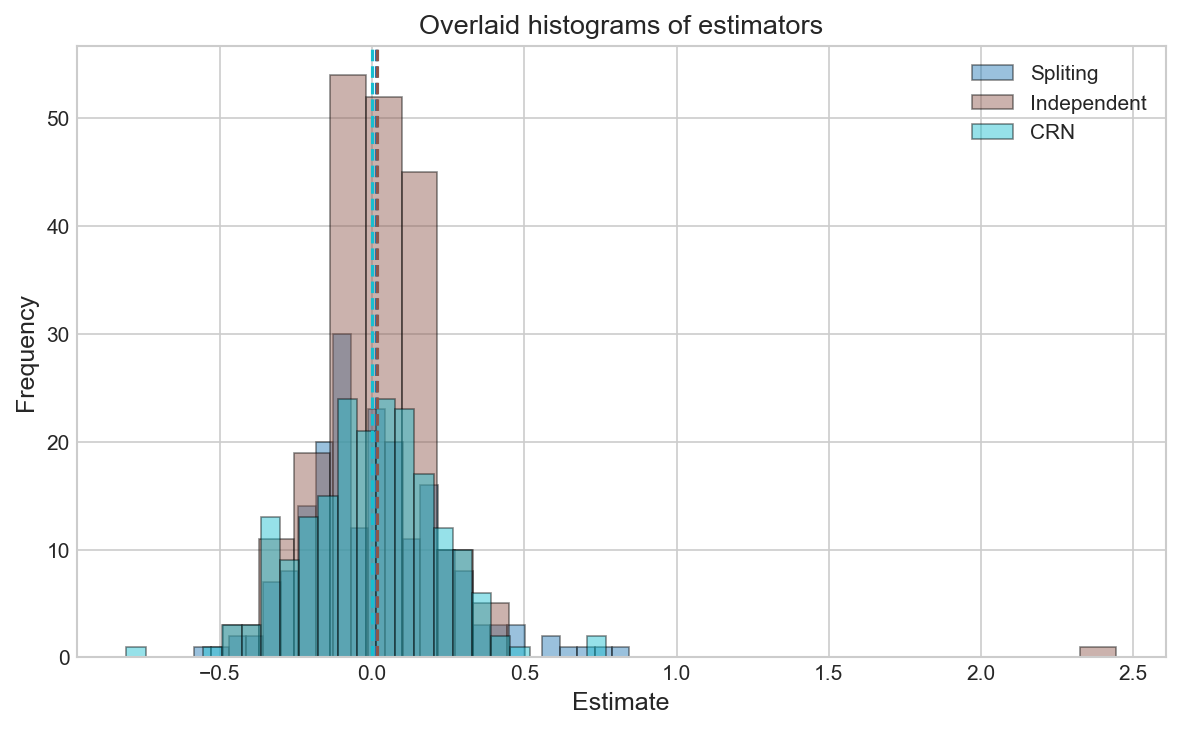

{'samples': [array([-0.12519001,  0.01692008,  0.48954081,  0.0871472 , -0.17379996,
         -0.32090288,  0.10694316,  0.00680245, -0.09579425, -0.07879639,
          0.03310963,  0.1006469 ,  0.24150797,  0.01272411, -0.31662019,
         -0.43695325,  0.21641384, -0.15376312, -0.04170914,  0.07246764,
         -0.03657726,  0.28584207, -0.26087884, -0.07244419,  0.61112709,
          0.22100591,  0.24592963, -0.18955746, -0.30342867,  0.77086702,
         -0.41192374, -0.02987355,  0.12017775,  0.60334279,  0.46294873,
         -0.26581214,  0.71693295, -0.18652189, -0.09972442, -0.09037782,
          0.33005666, -0.1914817 ,  0.15522841, -0.27468638,  0.84542919,
          0.48133973,  0.04849688, -0.28711021,  0.20225564, -0.17467592,
         -0.25282718, -0.0520964 , -0.0985904 , -0.18880936, -0.14452927,
          0.27782875,  0.39067151, -0.07313573,  0.1099335 , -0.11052982,
          0.31043266,  0.0012755 ,  0.16295656, -0.0188331 ,  0.04766354,
          0.08724918,  0.29

In [ ]:
plot_estimators_histograms(estimators,
    labels,
    nrep=300,
    bins=25,
)
